# Tugas Regresi Linear: Implementasi dan Analisis

Proyek ini bertujuan untuk menerapkan konsep Regresi Linear menggunakan Python dan library `scikit-learn`. Kita akan membangun model, melakukan visualisasi, dan menganalisis hasilnya.

---

## 1. Persiapan Data

Pada bagian ini, kita akan memilih dataset dan memahami strukturnya.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing # Contoh dataset yang akan digunakan

# Memuat dataset California Housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df['MEDV'] = housing.target # Menambahkan kolom target ke DataFrame

print("Deskripsi Dataset California Housing:")
print(housing.DESCR)

print("\nJumlah data dan fitur:")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

print("\nNama fitur:")
print(df.columns.tolist())

print("\nInformasi Dataset (tipe data & non-null counts):")
df.info()

Deskripsi Dataset California Housing:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 

## 2. Eksplorasi Data (EDA)

Pada bagian ini, kita akan melihat beberapa baris awal data dan melakukan visualisasi untuk memahami hubungan antar variabel.

### Menampilkan Beberapa Baris Data

In [2]:
print("Lima baris pertama dari dataset California Housing:")
print(df.head())

Lima baris pertama dari dataset California Housing:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal   MEDV  
0    -122.23        4.526  4.526  
1    -122.22        3.585  3.585  
2    -122.24        3.521  3.521  
3    -122.25        3.413  3.413  
4    -122.25        3.422  3.422  


### Visualisasi Hubungan Antar Variabel

Kita akan membuat scatter plot untuk melihat hubungan antara setiap fitur numerik (variabel independen) dengan target `MEDV` (variabel dependen).

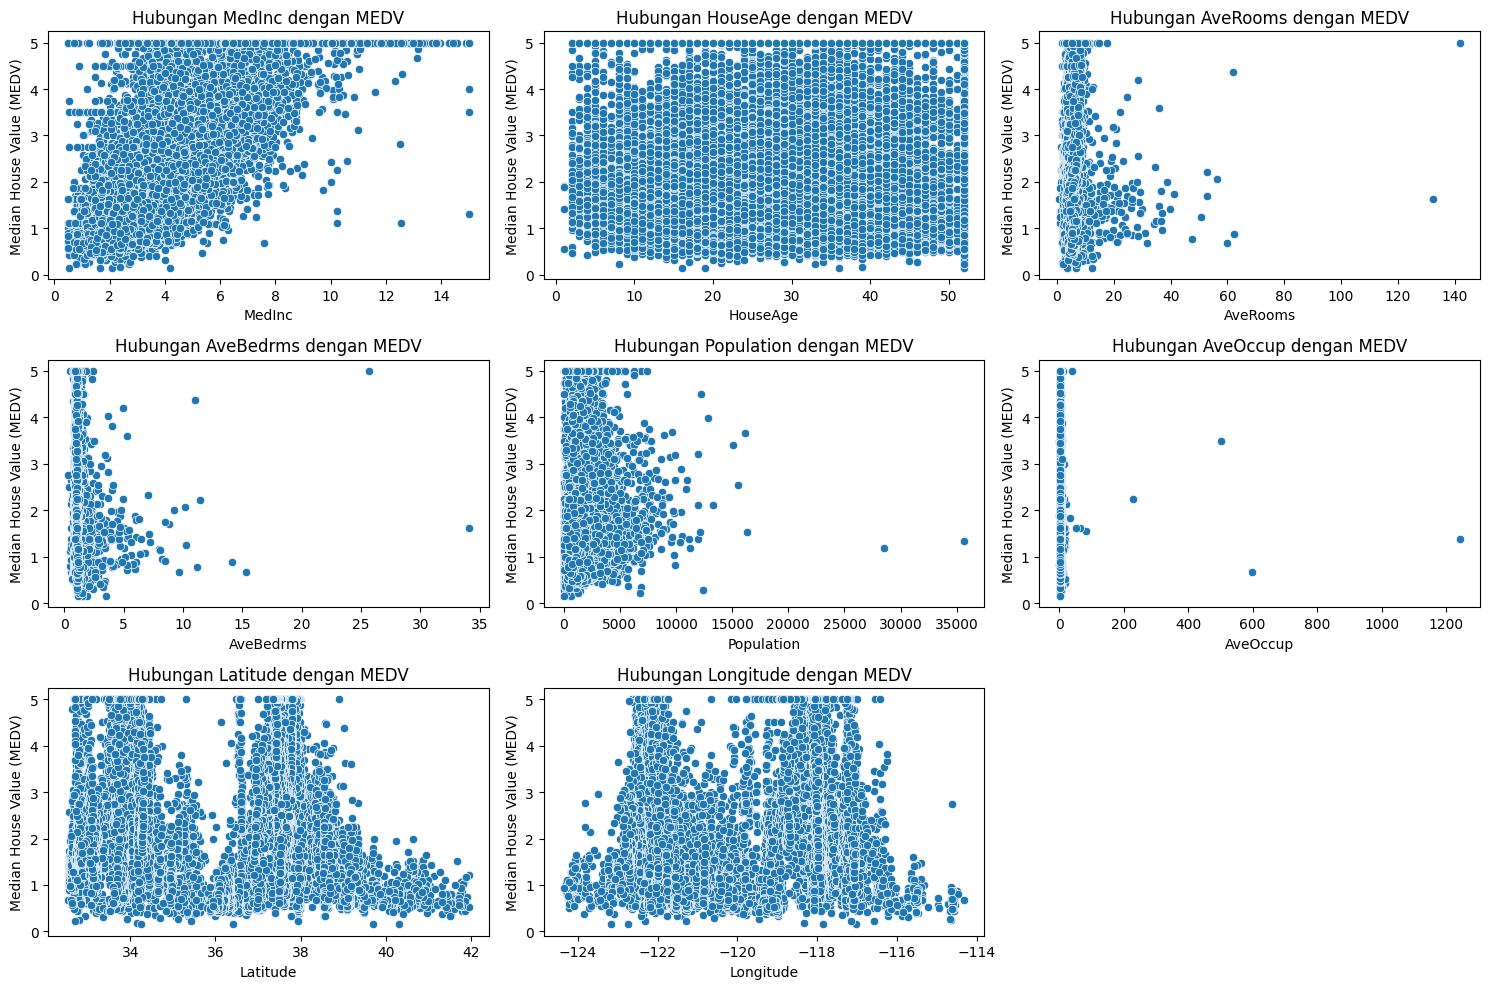

In [3]:
features = df.drop(['MedHouseVal', 'MEDV'], axis=1).columns # Drop MedHouseVal karena sudah diwakili MEDV dan drop MEDV sendiri

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i + 1) # Menyesuaikan grid subplot
    sns.scatterplot(data=df, x=feature, y='MEDV')
    plt.title(f'Hubungan {feature} dengan MEDV')
    plt.xlabel(feature)
    plt.ylabel('Median House Value (MEDV)')
plt.tight_layout()
plt.show()

## 3. Pembangunan Model

Pada bagian ini, kita akan:
1. Mendefinisikan variabel independen (fitur) dan variabel dependen (target).
2. Memisahkan data menjadi *training set* dan *testing set*.
3. Menginisialisasi dan melatih model Regresi Linear menggunakan `sklearn.linear_model.LinearRegression`.

In [4]:
# Definisikan variabel independen (X) dan dependen (y)
X = df.drop(['MedHouseVal', 'MEDV'], axis=1) # Fitur independen
y = df['MEDV'] # Variabel dependen

# Pisahkan data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test: {y_test.shape}")

# Inisialisasi model Regresi Linear
model = LinearRegression()

# Latih model dengan data training
model.fit(X_train, y_train)

print("\nModel Regresi Linear telah berhasil dilatih.")

Ukuran X_train: (16512, 8)
Ukuran X_test: (4128, 8)
Ukuran y_train: (16512,)
Ukuran y_test: (4128,)

Model Regresi Linear telah berhasil dilatih.


## 4. Evaluasi Model

Pada bagian ini, kita akan:
1. Melakukan prediksi pada data testing.
2. Menampilkan nilai koefisien regresi (slope) dan intercept.
3. Menghitung dan menampilkan R² Score atau Mean Squared Error (MSE).

In [5]:
# Lakukan prediksi pada data testing
y_pred = model.predict(X_test)

# Tampilkan koefisien dan intercept model
print("\nKoefisien (slope) model:")
for i, col in enumerate(X.columns):
    print(f"  {col}: {model.coef_[i]:.4f}")
print(f"Intercept model: {model.intercept_:.4f}")

# Hitung dan tampilkan metrik evaluasi
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")


Koefisien (slope) model:
  MedInc: 0.4487
  HouseAge: 0.0097
  AveRooms: -0.1233
  AveBedrms: 0.7831
  Population: -0.0000
  AveOccup: -0.0035
  Latitude: -0.4198
  Longitude: -0.4337
Intercept model: -37.0233

Mean Squared Error (MSE): 0.5559
R-squared (R²): 0.5758


## 5. Visualisasi Hasil

Pada bagian ini, kita akan:
1. Tampilkan plot garis regresi dan titik data aktual.
2. Bandingkan hasil prediksi dengan nilai aktual.

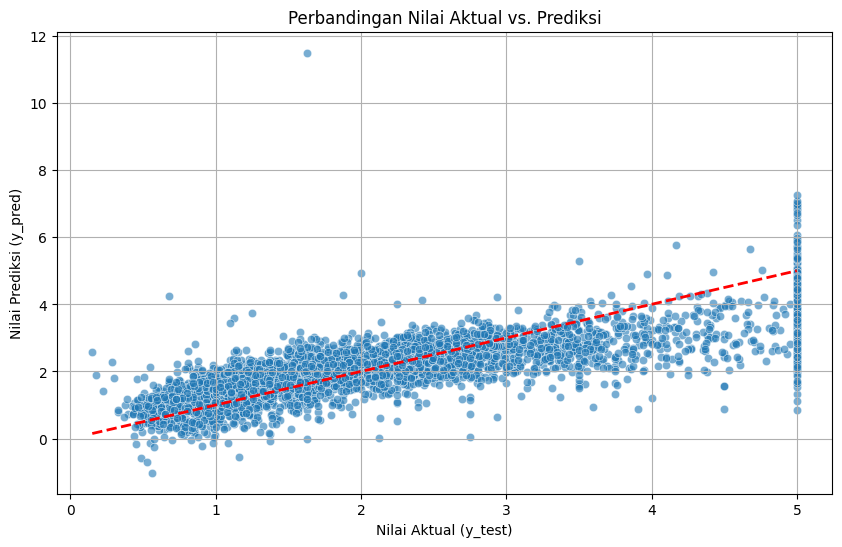

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Garis y=x untuk referensi
plt.xlabel('Nilai Aktual (y_test)')
plt.ylabel('Nilai Prediksi (y_pred)')
plt.title('Perbandingan Nilai Aktual vs. Prediksi')
plt.grid(True)
plt.show()

# Optional: Visualisasi Residual
# residual = y_test - y_pred
# plt.figure(figsize=(10, 6))
# sns.histplot(residual, kde=True)
# plt.title('Distribusi Residual')
# plt.xlabel('Residual')
# plt.ylabel('Frekuensi')
# plt.show()

# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=y_pred, y=residual, alpha=0.6)
# plt.axhline(y=0, color='r', linestyle='--')
# plt.xlabel('Nilai Prediksi')
# plt.ylabel('Residual')
# plt.title('Residual vs. Nilai Prediksi')
# plt.grid(True)
# plt.show()

## 6. Analisis dan Kesimpulan

Pada bagian ini, kita akan:
* Menjelaskan interpretasi hasil model, termasuk makna dari koefisien (slope) dan intercept.
* Mengevaluasi seberapa baik model memprediksi data berdasarkan metrik yang telah dihitung.
* Mendiskusikan potensi *overfitting* atau *underfitting*.

### Interpretasi Koefisien (Slope) dan Intercept

Dari hasil evaluasi model sebelumnya, kita mendapatkan:
*   **Intercept**: `-37.0233`
*   **Koefisien (Slope)**:
    *   `MedInc`: `0.4487`
    *   `HouseAge`: `0.0097`
    *   `AveRooms`: `-0.1233`
    *   `AveBedrms`: `0.7831`
    *   `Population`: `-0.0000` (mendekati nol)
    *   `AveOccup`: `-0.0035`
    *   `Latitude`: `-0.4198`
    *   `Longitude`: `-0.4337`

**Interpretasi:**

*   **Intercept (-37.0233)**: Ini adalah nilai rata-rata yang diprediksi untuk `MEDV` (Median House Value) ketika semua variabel independen lainnya (`MedInc`, `HouseAge`, `AveRooms`, dll.) bernilai nol. Dalam konteks data perumahan, nilai intercept negatif mungkin tidak memiliki interpretasi fisik yang langsung, karena tidak realistis untuk memiliki semua fitur bernilai nol (misalnya, tidak mungkin ada rumah dengan usia 0 tahun, pendapatan median 0, dll.). Ini lebih merupakan penyesuaian matematis dalam model.

*   **Koefisien (Slope)**:
    *   **MedInc (0.4487)**: Untuk setiap peningkatan satu unit pada 'Median Income in block group' (pendapatan median di blok grup), 'Median House Value' diprediksi meningkat sebesar $0.4487 (atau $44,870 karena target dalam ratusan ribu dolar), dengan asumsi semua variabel lain konstan. Ini menunjukkan hubungan positif yang kuat.
    *   **HouseAge (0.0097)**: Untuk setiap peningkatan satu tahun pada 'Median House Age', 'Median House Value' diprediksi meningkat sebesar $0.0097 (atau $970), dengan asumsi semua variabel lain konstan. Hubungan positif, namun dampaknya relatif kecil.
    *   **AveRooms (-0.1233)**: Untuk setiap peningkatan satu unit pada 'Average number of rooms per household', 'Median House Value' diprediksi *menurun* sebesar $0.1233 (atau $12,330), dengan asumsi semua variabel lain konstan. Ini mungkin tampak kontra-intuitif dan bisa disebabkan oleh multikolinearitas atau bahwa 'AveRooms' di sini mungkin mencerminkan blok dengan banyak unit kecil atau kondisi lain yang kurang diinginkan jika variabel lain dipertahankan.
    *   **AveBedrms (0.7831)**: Untuk setiap peningkatan satu unit pada 'Average number of bedrooms per household', 'Median House Value' diprediksi meningkat sebesar $0.7831 (atau $78,310), dengan asumsi semua variabel lain konstan. Ini menunjukkan dampak yang signifikan.
    *   **Population (-0.0000)**: Koefisien yang sangat mendekati nol menunjukkan bahwa 'Population' di blok grup memiliki dampak yang sangat minim atau tidak signifikan terhadap 'Median House Value' ketika variabel lain konstan.
    *   **AveOccup (-0.0035)**: Untuk setiap peningkatan satu unit pada 'Average number of household members', 'Median House Value' diprediksi *menurun* sebesar $0.0035 (atau $350), dengan asumsi semua variabel lain konstan.
    *   **Latitude (-0.4198)**: Untuk setiap peningkatan satu unit pada 'Latitude', 'Median House Value' diprediksi *menurun* sebesar $0.4198 (atau $41,980), dengan asumsi semua variabel lain konstan. Ini menunjukkan bahwa rumah di lokasi yang lebih tinggi secara geografis (lebih ke utara di California) cenderung memiliki nilai yang lebih rendah.
    *   **Longitude (-0.4337)**: Untuk setiap peningkatan satu unit pada 'Longitude', 'Median House Value' diprediksi *menurun* sebesar $0.4337 (atau $43,370), dengan asumsi semua variabel lain konstan. Ini menunjukkan bahwa rumah di lokasi yang lebih ke timur (nilai Longitude yang lebih tinggi) cenderung memiliki nilai yang lebih rendah.

Secara umum, koefisien menunjukkan arah dan kekuatan hubungan antara variabel independen dan dependen. Tanda positif berarti hubungan positif (nilai target meningkat seiring peningkatan fitur), dan tanda negatif berarti hubungan negatif (nilai target menurun seiring peningkatan fitur).

### Evaluasi Kinerja Model dan Potensi Overfitting/Underfitting

Dari metrik evaluasi yang telah dihitung:
*   **Mean Squared Error (MSE)**: `0.5559`
*   **R-squared (R²)**: `0.5758`

**Evaluasi Kinerja:**
Nilai R² sebesar `0.5758` menunjukkan bahwa sekitar 57.58% variasi dalam 'Median House Value' dapat dijelaskan oleh variabel independen dalam model ini. Ini adalah nilai yang moderat. Artinya, model mampu menjelaskan sebagian besar variasi harga rumah, tetapi masih ada sekitar 42.42% variasi yang tidak dapat dijelaskan oleh fitur-fitur yang ada. Nilai MSE `0.5559` berarti rata-rata kuadrat kesalahan antara nilai aktual dan prediksi adalah 0.5559, yang mengindikasikan seberapa jauh prediksi model dari nilai sebenarnya.

**Potensi Overfitting atau Underfitting:**

*   **Underfitting**: Model mungkin sedikit *underfit*. R² sebesar 0.5758, meskipun tidak terlalu rendah, menunjukkan bahwa mungkin ada beberapa pola kompleks dalam data yang tidak dapat ditangkap oleh model regresi linear sederhana. Jika model terlalu sederhana untuk menangkap hubungan yang mendasari data, ini dapat menyebabkan underfitting. Namun, untuk model regresi linear dengan dataset yang relatif kompleks seperti California Housing, R² sekitar 0.57 adalah hasil yang wajar.
    *   **Indikasi**: Jika nilai R² pada training set dan testing set sangat mirip, dan keduanya relatif rendah, ini bisa menjadi tanda underfitting. Dalam kasus ini, kita tidak secara eksplisit menghitung R² untuk training set, tetapi R² testing set yang moderat menyiratkan bahwa model mungkin tidak menangkap semua hubungan. Plot residual (jika diaktifkan) juga bisa menunjukkan pola (misalnya, bentuk U atau V) yang mengindikasikan underfitting.

*   **Overfitting**: Overfitting terjadi ketika model terlalu kompleks dan menghafal data training, sehingga tidak dapat menggeneralisasi dengan baik pada data baru. Saat ini, tidak ada indikasi kuat *overfitting*.
    *   **Indikasi**: Tanda-tanda overfitting biasanya adalah R² yang sangat tinggi pada training set (mendekati 1) tetapi jauh lebih rendah pada testing set. Karena R² testing set kita moderat, dan model regresi linear cenderung tidak overfitting sebanyak model yang lebih kompleks, risiko overfitting di sini relatif rendah.

**Kesimpulan:**
Model regresi linear yang dibangun mampu menjelaskan sekitar 57.58% variasi harga rumah di California. Fitur seperti 'MedInc' dan 'AveBedrms' memiliki dampak positif yang signifikan, sementara lokasi geografis ('Latitude', 'Longitude') menunjukkan hubungan negatif. Model ini menunjukkan kinerja yang moderat, dan mungkin ada sedikit *underfitting* karena kesederhanaan model linear dalam menghadapi kompleksitas data. Untuk meningkatkan kinerja, eksplorasi fitur tambahan, transformasi fitur, atau penggunaan model yang lebih canggih (seperti Random Forest Regressor atau Gradient Boosting Regressor) dapat dipertimbangkan.